In [1]:
import random

states = ["Start", "Middle", "End"]
actions = ["Attack", "Defend"]

rewards = {
    ("Start", "Attack"): 5,
    ("Start", "Defend"): 2,
    ("Middle", "Attack"): 8,
    ("Middle", "Defend"): 4,
    ("End", "Attack"): 10,
    ("End", "Defend"): 6
}

state = "Start"

for i in range(5):
    action = random.choice(actions)
    reward = rewards[(state, action)]
    print("State:", state,
          "Action:", action,
          "Reward:", reward)

    if state == "Start":
        state = "Middle"
    elif state == "Middle":
        state = "End"

State: Start Action: Defend Reward: 2
State: Middle Action: Attack Reward: 8
State: End Action: Attack Reward: 10
State: End Action: Defend Reward: 6
State: End Action: Attack Reward: 10


In [2]:
import random

rooms = ["Kitchen", "Bedroom", "Hall"]

for episode in range(5):
    room = random.choice(rooms)

    if room == "Kitchen":
        reward = 10
    elif room == "Hall":
        reward = 5
    else:
        reward = 2

    print("Episode:", episode + 1)
    print("Visited:", room)
    print("Reward:", reward)

Episode: 1
Visited: Hall
Reward: 5
Episode: 2
Visited: Hall
Reward: 5
Episode: 3
Visited: Bedroom
Reward: 2
Episode: 4
Visited: Hall
Reward: 5
Episode: 5
Visited: Kitchen
Reward: 10


In [3]:
states = ["A", "B", "Goal"]

actions = {
    "A": ["Right"],
    "B": ["Right"],
    "Goal": []
}

reward = {
    ("A", "Right"): 5,
    ("B", "Right"): 10
}

state = "A"

while state != "Goal":
    action = actions[state][0]
    print(state, "->", action)

    if state == "A":
        state = "B"
    elif state == "B":
        state = "Goal"

print("Reached Goal")

A -> Right
B -> Right
Reached Goal


In [4]:
gamma = 0.9

reward = [5, 10, 20]

V = [0, 0, 0]

for i in range(2, -1, -1):
    if i == 2:
        V[i] = reward[i]
    else:
        V[i] = reward[i] + gamma * V[i + 1]

print("State Values")

for i in range(3):
    print("State", i, ":", V[i])

State Values
State 0 : 30.2
State 1 : 28.0
State 2 : 20


In [5]:
import random

epsilon = 0.2

arms = [2, 5, 8]

counts = [0, 0, 0]

for i in range(20):

    if random.random() < epsilon:
        arm = random.randint(0, 2)
    else:
        arm = arms.index(max(arms))

    counts[arm] += 1

print("Selection Count")

for i in range(3):
    print("Arm", i + 1, counts[i])

Selection Count
Arm 1 0
Arm 2 1
Arm 3 19


Training completed.
Final Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Average reward: 0.0


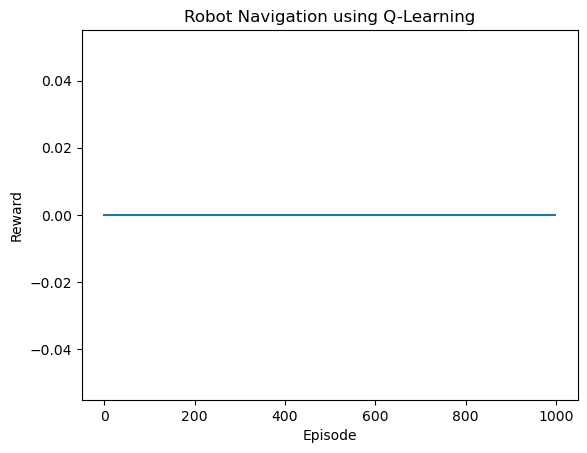

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery=False)

Q = np.zeros((env.observation_space.n, env.action_space.n))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 1000
rewards = []

for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(100):

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        Q[state, action] += alpha * (
            reward +
            gamma * np.max(Q[next_state]) -
            Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)

env.close()

print("Training completed.")
print("Final Q-table:")
print(Q)

print("Average reward:",
      np.mean(rewards[-100:]))

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Robot Navigation using Q-Learning")
plt.show()

In [2]:
import numpy as np

# Grid size
rows = 5
cols = 5

# Goal location
goal = (4, 4)

# Obstacles
obstacles = [(1, 1), (2, 2), (3, 3)]

# Value function
V = np.zeros((rows, cols))

# Actions
actions = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

gamma = 0.9

def next_state(state, action):

    r, c = state
    dr, dc = actions[action]

    nr = r + dr
    nc = c + dc

    if nr < 0 or nr >= rows:
        return state

    if nc < 0 or nc >= cols:
        return state

    if (nr, nc) in obstacles:
        return state

    return (nr, nc)


# Value Iteration
for iteration in range(100):

    new_V = V.copy()

    for r in range(rows):
        for c in range(cols):

            state = (r, c)

            if state == goal:
                continue

            if state in obstacles:
                continue

            values = []

            for action in actions:

                ns = next_state(state, action)

                if ns == goal:
                    reward = 10
                else:
                    reward = -1

                nr, nc = ns

                value = reward + gamma * V[nr, nc]

                values.append(value)

            new_V[r, c] = max(values)

    if np.max(np.abs(new_V - V)) < 0.001:
        break

    V = new_V


print("Optimal Value Function:")
print(np.round(V, 2))


# Extract policy
policy = {}

for r in range(rows):
    for c in range(cols):

        state = (r, c)

        if state == goal or state in obstacles:
            continue

        best_action = None
        best_value = -np.inf

        for action in actions:

            ns = next_state(state, action)
            nr, nc = ns

            value = V[nr, nc]

            if value > best_value:
                best_value = value
                best_action = action

        policy[state] = best_action


print("\nOptimal Taxi Policy:")

for state, action in policy.items():
    print(state, "->", action)

Optimal Value Function:
[[-0.43  0.63  1.81  3.12  4.58]
 [ 0.63  0.    3.12  4.58  6.2 ]
 [ 1.81  3.12  0.    6.2   8.  ]
 [ 3.12  4.58  6.2   0.   10.  ]
 [ 4.58  6.2   8.   10.    0.  ]]

Optimal Taxi Policy:
(0, 0) -> DOWN
(0, 1) -> RIGHT
(0, 2) -> DOWN
(0, 3) -> DOWN
(0, 4) -> DOWN
(1, 0) -> DOWN
(1, 2) -> RIGHT
(1, 3) -> DOWN
(1, 4) -> DOWN
(2, 0) -> DOWN
(2, 1) -> DOWN
(2, 3) -> RIGHT
(2, 4) -> DOWN
(3, 0) -> DOWN
(3, 1) -> DOWN
(3, 2) -> DOWN
(3, 4) -> LEFT
(4, 0) -> RIGHT
(4, 1) -> RIGHT
(4, 2) -> RIGHT
(4, 3) -> UP


In [3]:
import numpy as np
import random

# States
states = [
    "Room1",
    "Room2",
    "Room3",
    "Room4",
    "Clean"
]

actions = ["Left", "Right", "Clean"]

Q = {
    state: {action: 0.0 for action in actions}
    for state in states
}

returns = {
    state: {action: [] for action in actions}
    for state in states
}

gamma = 0.9
episodes = 1000


def choose_action(state):

    if random.random() < 0.2:
        return random.choice(actions)

    return max(
        Q[state],
        key=Q[state].get
    )


def transition(state, action):

    if action == "Clean":
        return "Clean", 10

    if state == "Room1":
        return "Room2", -1

    if state == "Room2":
        return "Room3", -1

    if state == "Room3":
        return "Room4", -1

    if state == "Room4":
        return "Clean", -1

    return "Clean", 0


for episode in range(episodes):

    state = "Room1"
    episode_data = []

    for step in range(20):

        action = choose_action(state)

        next_state, reward = transition(
            state, action
        )

        episode_data.append(
            (state, action, reward)
        )

        state = next_state

        if state == "Clean":
            break

    # Calculate returns
    G = 0

    visited = set()

    for state, action, reward in reversed(episode_data):

        G = gamma * G + reward

        if (state, action) not in visited:

            returns[state][action].append(G)

            Q[state][action] = np.mean(
                returns[state][action]
            )

            visited.add((state, action))


print("Learned Q-values:")

for state in states:

    print("\n", state)

    for action in actions:

        print(
            action,
            ":",
            round(Q[state][action], 3)
        )


print("\nOptimal Cleaning Policy:")

for state in states:

    best_action = max(
        Q[state],
        key=Q[state].get
    )

    print(state, "->", best_action)

Learned Q-values:

 Room1
Left : 7.362
Right : 7.376
Clean : 10.0

 Room2
Left : 6.326
Right : 6.564
Clean : 10.0

 Room3
Left : 6.762
Right : 7.175
Clean : 10.0

 Room4
Left : -1.0
Right : 0.0
Clean : 10.0

 Clean
Left : 0.0
Right : 0.0
Clean : 0.0

Optimal Cleaning Policy:
Room1 -> Clean
Room2 -> Clean
Room3 -> Clean
Room4 -> Clean
Clean -> Left


In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Grid
rows = 5
cols = 5

start = (0, 0)
goal = (4, 4)

obstacles = [
    (1, 1),
    (2, 2),
    (3, 2)
]

actions = [
    (0, -1),   # Left
    (0, 1),    # Right
    (-1, 0),   # Up
    (1, 0)     # Down
]

n_actions = 4

alpha = 0.1
gamma = 0.9
epsilon = 0.1


def move(state, action):

    r, c = state
    dr, dc = actions[action]

    nr = r + dr
    nc = c + dc

    if nr < 0 or nr >= rows:
        return state

    if nc < 0 or nc >= cols:
        return state

    if (nr, nc) in obstacles:
        return state

    return (nr, nc)


def reward(state):

    if state == goal:
        return 10

    return -1


def choose_action(Q, state):

    r, c = state

    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)

    return np.argmax(Q[r, c])


# -----------------------------
# TD(0)
# -----------------------------

V = np.zeros((rows, cols))

for episode in range(500):

    state = start

    for step in range(100):

        action = random.randint(0, 3)

        next_state = move(state, action)

        r, c = state
        nr, nc = next_state

        R = reward(next_state)

        V[r, c] += alpha * (
            R +
            gamma * V[nr, nc] -
            V[r, c]
        )

        state = next_state

        if state == goal:
            break


print("TD(0) Value Function:")
print(np.round(V, 2))


# -----------------------------
# SARSA
# -----------------------------

Q_sarsa = np.zeros(
    (rows, cols, n_actions)
)

for episode in range(1000):

    state = start

    action = choose_action(
        Q_sarsa,
        state
    )

    for step in range(100):

        next_state = move(state, action)

        R = reward(next_state)

        next_action = choose_action(
            Q_sarsa,
            next_state
        )

        r, c = state
        nr, nc = next_state

        Q_sarsa[r, c, action] += alpha * (
            R +
            gamma *
            Q_sarsa[nr, nc, next_action]
            -
            Q_sarsa[r, c, action]
        )

        state = next_state
        action = next_action

        if state == goal:
            break


# -----------------------------
# Q-Learning
# -----------------------------

Q_learning = np.zeros(
    (rows, cols, n_actions)
)

for episode in range(1000):

    state = start

    for step in range(100):

        action = choose_action(
            Q_learning,
            state
        )

        next_state = move(
            state,
            action
        )

        R = reward(next_state)

        r, c = state
        nr, nc = next_state

        Q_learning[r, c, action] += alpha * (
            R +
            gamma *
            np.max(Q_learning[nr, nc])
            -
            Q_learning[r, c, action]
        )

        state = next_state

        if state == goal:
            break


print("\nSARSA Q-table:")
print(np.round(Q_sarsa, 2))

print("\nQ-Learning Q-table:")
print(np.round(Q_learning, 2))


# Compare learned policies

print("\nOptimal Policy using Q-Learning:")

symbols = ["←", "→", "↑", "↓"]

for r in range(rows):

    row = ""

    for c in range(cols):

        if (r, c) == goal:
            row += " G "

        elif (r, c) in obstacles:
            row += " X "

        else:
            action = np.argmax(
                Q_learning[r, c]
            )

            row += f" {symbols[action]} "

    print(row)
    

TD(0) Value Function:
[[-9.63 -9.48 -9.16 -8.39 -8.39]
 [-9.7   0.   -8.77 -7.57 -7.07]
 [-9.6  -9.53  0.   -4.19 -3.81]
 [-9.34 -8.93  0.   -2.29  2.14]
 [-8.94 -7.86 -4.39  2.12  0.  ]]

SARSA Q-table:
[[[-2.58 -3.35 -2.75 -1.2 ]
  [-2.89 -2.41 -2.93 -2.89]
  [-2.14 -1.06 -2.25 -2.16]
  [-1.68 -1.51 -1.43  0.73]
  [-1.16 -1.01 -0.93 -0.54]]

 [[-1.56 -1.78 -2.83 -0.27]
  [ 0.    0.    0.    0.  ]
  [-1.68 -0.63 -1.75 -1.56]
  [-1.2  -0.84 -0.99  2.22]
  [-0.61 -0.74 -0.64  2.13]]

 [[-0.77 -0.22 -1.75  0.76]
  [-1.23 -1.02 -1.09  1.9 ]
  [ 0.    0.    0.    0.  ]
  [-0.56  5.03 -0.2  -0.08]
  [ 0.43 -0.29 -0.31  7.57]]

 [[ 0.32  2.04 -0.63  1.62]
  [ 0.1   1.83 -0.19  3.68]
  [ 0.    0.    0.    0.  ]
  [-0.29 -0.2  -0.11  7.3 ]
  [ 0.31  2.43  0.52  9.99]]

 [[-1.1   3.66 -0.76 -0.33]
  [ 1.89  5.81  1.7   3.13]
  [ 3.07  7.89  5.57  4.95]
  [ 3.95 10.    4.47  7.43]
  [ 0.    0.    0.    0.  ]]]

Q-Learning Q-table:
[[[-1.73 -2.75 -1.55 -0.43]
  [-2.67 -1.44 -2.81 -2.75]
  [-2.21 